In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/revision/supplement-extra"
setup_plotting(figure_dir, display_dpi=300, save_dpi=300)

import os

import scanpy as sc

from spatial_tcr.colors import cell_to_group, colors_sub
from spatial_tcr.plotting import (
    plot_cell_types_per_domain_stacked,
    plot_tcell_infiltrate_per_domain_stacked,
)

## Load data

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.2-kidney_tcr_clonal_clusters_peri_glom_annot.h5ad"
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

/tmp/ipykernel_2422689/3806261845.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color=["tcell_infiltrate"], spot_size=10)


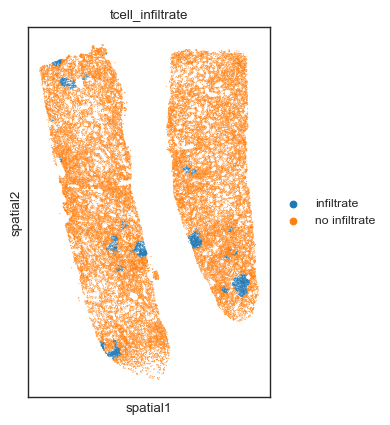

In [3]:
samples = adata.obs["sample"].unique()
ad_sub = adata[adata.obs["sample"].isin(samples[0:1])].copy()
sc.pl.spatial(ad_sub, color=["tcell_infiltrate"], spot_size=10)

## Characterization in terms of cell phenotypes

In [4]:
adata.obs.columns

Index(['sample', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'control_codeword_counts',
       'unassigned_codeword_counts', 'deprecated_codeword_counts',
       'total_counts', 'cell_area', 'nucleus_area', 'slide',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts',
       'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob',
       'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B',
       'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST',
       'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC',
       'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P',
       'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden',
       'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density',
   

In [5]:
adata.obs["in_glom"].value_counts()

in_glom
False    371180
True      18210
Name: count, dtype: int64

In [6]:
adata.obs["tcell_infiltrate"].value_counts()

tcell_infiltrate
no infiltrate    360934
infiltrate        28456
Name: count, dtype: int64

/tmp/ipykernel_2422689/1427926715.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub, color=["domain"], spot_size=10)


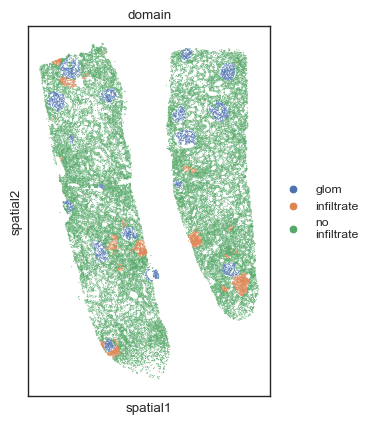

In [7]:
# make sure overlap with gloms is resolved
adata.obs["domain"] = adata.obs["tcell_infiltrate"].astype(str)
adata.obs.loc[adata.obs["in_glom"], "domain"] = "glom"
adata.obs.loc[adata.obs["domain"] == "no infiltrate", "domain"] = "no\ninfiltrate"

ad_sub = adata[adata.obs["sample"].isin(samples[0:1])].copy()
sc.pl.spatial(ad_sub, color=["domain"], spot_size=10)

In [8]:
adata.obs["cell_type_l0"] = adata.obs["cell_type_l2"].astype(str).replace(cell_to_group)

In [9]:
ct_counts = (
    adata.obs.groupby(["domain"], observed=True)["cell_type_l0"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
ct_counts = ct_counts.loc[["infiltrate", "no\ninfiltrate", "glom"]]
ct_counts

cell_type_l0,APC,CD4+,CD8+,MAIT,NKT-like,PapE,Tregs,gdT,glom. cell,other immune,other kidney cell,pDC
domain,,,,,,,,,,,,
infiltrate,0.259709,0.115979,0.070929,0.010486,0.009780,0.000106,0.014122,0.003531,0.003213,0.039331,0.472497,0.000318
no\ninfiltrate,0.136078,0.016855,0.012658,0.001458,0.003800,0.000061,0.002097,0.000971,0.004661,0.020262,0.801030,0.000067
glom,0.069522,0.003350,0.004448,0.000549,0.005711,0.000000,0.000879,0.000384,0.521966,0.008347,0.384843,0.000000


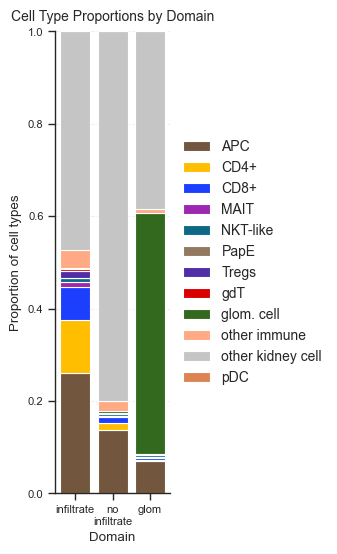

In [11]:
fig, ax = plot_cell_types_per_domain_stacked(
    ct_counts,
    title="Cell Type Proportions by Domain",
    colors_dict=colors_sub,
    save_path=os.path.join(figure_dir, "cell_type_proportions_by_domain.pdf"),
)

## Characterization in terms of clonotypes

In [12]:
# Change category name using .cat.rename_categories for categorical dtype
adata.obs["tcell_infiltrate"] = adata.obs["tcell_infiltrate"].cat.rename_categories(
    {
        cat: "no\ninfiltrate" if cat == "no infiltrate" else cat
        for cat in adata.obs["tcell_infiltrate"].cat.categories
    }
)

clone_counts = (
    adata.obs.loc[adata.obs["avbv_clone"].notna()]
    .groupby(["tcell_infiltrate"], observed=True)["avbv_clone"]
    .value_counts(normalize=False)
    .unstack()
    .fillna(0)
)
# Order columns by cumulative abundance (sum across all rows), descending
clone_counts = clone_counts.loc[
    :, clone_counts.sum(axis=0).sort_values(ascending=False).index
]
clone_counts = clone_counts.loc[["infiltrate", "no\ninfiltrate"]]

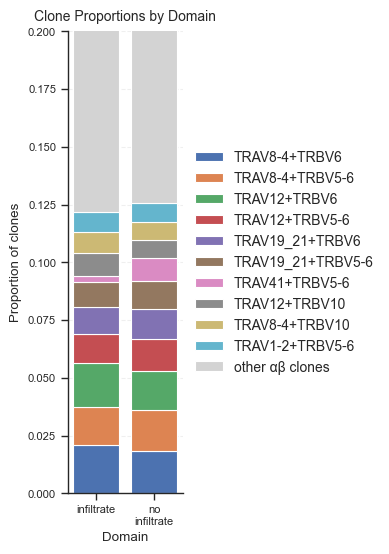

In [13]:
from spatial_tcr.plotting import plot_clone_counts_per_domain_stacked

fig, ax = plot_clone_counts_per_domain_stacked(
    clone_counts,
    top_n=10,
    normalize=True,  # or False for counts
    title="Clone Proportions by Domain",
    ylim_max=0.2,
    save_path=os.path.join(figure_dir, "clone_proportions_by_domain.pdf"),
)

### Check per sample

In [ ]:
adata.obs["sample_short"] = (
    adata.obs["sample"]
    .astype(str)
    .replace({s: f"S{i}" for i, s in enumerate(adata.obs["sample"].unique())})
)

for sample in adata.obs["sample_short"].unique():
    ad_sub = adata[adata.obs["sample_short"] == sample].copy()
    obs = ad_sub.obs.loc[ad_sub.obs["avbv_clone"].notna()]
    if "infiltrate" not in obs["tcell_infiltrate"].unique():
        continue
    clone_counts = (
        obs.groupby(["tcell_infiltrate"], observed=True)["avbv_clone"]
        .value_counts(normalize=False)
        .unstack()
        .fillna(0)
    )
    # Order columns by cumulative abundance (sum across all rows), descending
    clone_counts = clone_counts.loc[
        :, clone_counts.sum(axis=0).sort_values(ascending=False).index
    ]
    clone_counts = clone_counts.loc[["infiltrate", "no\ninfiltrate"]]

    fig, ax = plot_clone_counts_per_domain_stacked(
        clone_counts,
        top_n=10,
        normalize=True,  # or False for counts
        title=f"Clone Proportions by Domain\n(sample {sample})",
        ylim_max=0.2,
    )

## Characterize localization

In [16]:
adata.obs.columns

Index(['sample', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'control_codeword_counts',
       'unassigned_codeword_counts', 'deprecated_codeword_counts',
       'total_counts', 'cell_area', 'nucleus_area', 'slide',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts',
       'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob',
       'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B',
       'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST',
       'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC',
       'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P',
       'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden',
       'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density',
   

In [17]:
adata.obs["tcell_infiltrate"].value_counts()

tcell_infiltrate
no\ninfiltrate    360934
infiltrate         28456
Name: count, dtype: int64

In [14]:
adata.obs["domain_new"] = "tubulointerstitial"
adata.obs.loc[adata.obs["in_glom"], "domain_new"] = "glomerular"
adata.obs.loc[adata.obs["in_peri_glom"], "domain_new"] = "periglomerular"

adata.obs["domain_new"].value_counts()

domain_new
tubulointerstitial    305409
periglomerular         65771
glomerular             18210
Name: count, dtype: int64

(<Figure size 150x300 with 1 Axes>,
 <Axes: title={'center': 'T cell infiltrate proportions per domain'}, xlabel='Domain', ylabel='Proportion of cells'>)

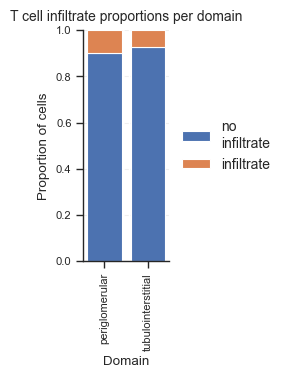

In [15]:
plot_tcell_infiltrate_per_domain_stacked(
    adata,
    title="T cell infiltrate proportions per domain",
    figsize=(1.5, 3),
    exclude_domains=["glomerular"],
    save_path=os.path.join(figure_dir, "tcell_infiltrate_proportions_per_domain.pdf"),
)